# 02 · Sweeps, averaging, and what comes back

Part 1 built programs that do one thing, once. Every calibration you will ever run is a loop:
step a knob, measure, step it again, and look at the shape of what came back. This part is about
the three pieces that turn a sequence into an experiment.

- **Variables and expressions** are the parametric holes in a program.
- **Sweep sources** say how a variable moves, in a form a compiler can read.
- **`average(shots)`** repeats the whole thing and hands you a mean instead of one sample.

Then the other half: what `qp.simulate` gives back, why it is an `xarray.DataArray`, and how the
dimension names come from the variables you declared.

Two experiments carry it. **Resonator spectroscopy** finds the readout resonator, which is the
first measurement anyone makes on a new chip. **Punchout** is the 2D scan that shows the resonator
sliding as you push more power at it, and it tells you what power to read out at. About 35 minutes.

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "qprogram[viz]==0.1.0", "scipy"],
        check=True,
    )
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.1.0


In [2]:
import matplotlib.pyplot as plt
import numpy as np

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram.buses import BusSchema
from qprogram.waveforms import Square

schema = BusSchema.transmon()
q = schema.q

print("readout bus:", q[0].readout, "| channel:", q[0].readout.channel,
      "| has ADC:", q[0].readout.acquires)

readout bus: q0/readout | channel: IQ | has ADC: True


## The device under test

Every notebook in this tutorial talks to the same simulated chip, and every notebook writes its
true parameters down in one place. That is the deal: the numbers are in plain sight, and the job of
each experiment is to recover them from data. If your fit disagrees with `DEVICE`, either the fit
is wrong or you learned something about the analysis.

Part 2 needs three of these numbers: where the readout resonator sits, how wide it is, and how far
the qubit pulls it.

In [3]:
DEVICE = {
    # qubit 0
    "q0_f01": 4.85e9,        # Hz, at the flux sweet spot
    "q0_fr": 7.20e9,         # Hz, readout resonator
    "q0_kappa": 1.5e6,       # Hz, resonator linewidth (FWHM)
    "q0_chi": -1.8e6,        # Hz, dispersive shift
    "q0_a_pi": 0.62,         # drive amplitude of a pi pulse (DAC units)
    "q0_T1": 18_000,         # ns
    "q0_T2star": 9_000,      # ns
    "q0_T2echo": 16_000,     # ns
    "q0_linewidth": 2.0e6,   # Hz, spectroscopy FWHM at low power
    # qubit 1
    "q1_f01": 5.12e9,
    "q1_fr": 7.35e9,
    "q1_a_pi": 0.55,
    "q1_T1": 15_000,
}

print(f"resonator        {DEVICE['q0_fr'] / 1e9:.3f} GHz")
print(f"linewidth kappa  {DEVICE['q0_kappa'] / 1e6:.2f} MHz")
print(f"dispersive shift {DEVICE['q0_chi'] / 1e6:+.2f} MHz")

resonator        7.200 GHz
linewidth kappa  1.50 MHz
dispersive shift -1.80 MHz


## 2.1 A variable is a hole in the program

You do not know where the resonator is. You know it is somewhere near 7.2 GHz, because that is
where the designer put it and the chip came back within a percent or two. So you cannot write
`set_frequency(readout, 7.2e9)` and be done: you have to write the program once with a hole in it,
and let something else decide what goes in the hole.

`program.variable(id, label=..., units=...)` declares that hole. The id is the only part that
matters to the machine: it becomes the identifier in the `.qp` file and the dimension name in the
result. `label` and `units` are for humans.

Arithmetic on a variable builds an expression tree. Nothing is computed at that point.
`freq - 7.2e9` is a `BinaryOp` node holding a variable and a constant, and you can print it, walk
it, serialize it, or hand it to any operation that takes a number.

In [4]:
scratch = qp.QProgram(label="expressions", schema=schema)
freq = scratch.variable("freq", label="Readout frequency", units="Hz")
amp = scratch.variable("amp", label="Readout amplitude", units="V")

# Detuning from the resonator, in half-linewidths. This is data, not a number.
detuning = (freq - DEVICE["q0_fr"]) / (DEVICE["q0_kappa"] / 2)

print("the expression:  ", detuning)
print("free variables:  ", sorted(v.id for v in detuning.variables()))
print("value of freq:   ", freq.value)

the expression:   ((Variable('freq') - Constant(7200000000.0)) / Constant(750000.0))
free variables:   ['freq']
value of freq:    UNASSIGNED


### Where the value comes from

A variable holds one value at a time, and it starts out as `UNASSIGNED`. The loop that binds it is
what sets it: on each iteration the runtime calls `set_value`, every expression built on that
variable re-evaluates, and the operations inside the loop see the new number. Nothing is passed as
an argument anywhere.

Two ways to read a tree. `evaluate()` returns `UNASSIGNED` if anything in it is unbound, so code
that inspects a program before it has run never has to guard. `evaluate_or_raise()` insists on a
number and raises `UnassignedVariableError` naming what is missing. That is the one the interpreter
calls on every operation as it executes, because by then there is no value it is allowed to skip.

In [5]:
print("unbound:", detuning.evaluate())   # UNASSIGNED propagates up through the whole tree

freq.set_value(7.2015e9)                 # the loop does exactly this, once per iteration
print("bound:  ", detuning.evaluate())   # 1.5 MHz above resonance is 2.0 half-linewidths
freq.reset()

try:
    detuning.evaluate_or_raise()
except qp.UnassignedVariableError as err:
    print("evaluate_or_raise:", sorted(v.id for v in err.free_variables), "still unbound")

# A waveform parameter is one more slot an expression fits into.
tone = Square(amplitude=amp / 2, duration=8)
amp.set_value(0.8)
print("envelope:", tone.envelope())      # half of 0.8, eight samples of it
amp.reset()

unbound: UNASSIGNED
bound:   2.0
evaluate_or_raise: ['freq'] still unbound
envelope: [0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]


## 2.2 Sweep sources: how the variable moves

`program.sweep(variable, source)` is the only loop in QProgram. There is no separate `for_loop` and
no `while`. What changes between a frequency ramp and a table of calibrated phases is the
**source**, and a source is a small immutable value object, the sweep analogue of a waveform.

| Source | Kind | Reach for it when |
|---|---|---|
| `qp.Range(start, stop, step)` | linear | you know the spacing |
| `qp.Linspace(start, stop, num)` | linear | you know the point count |
| `qp.Values(seq)` | arbitrary | you have a list: calibrated values, a measured table |
| `qp.Logspace(start, stop, num)` | arbitrary | powers and decay times, anything spanning decades |
| `qp.File(path)` | arbitrary | the list lives in a `.npy` file next to the program |
| `qp.Repeat(src, times)` | arbitrary | the same sweep back to back |
| `qp.Rotate(src, by)` | arbitrary | the same sweep, cyclically shifted |
| `qp.Concat([src, src])` | arbitrary | several sweeps end to end |

One thing to fix in your head now, because it will bite you otherwise: **`Range` includes its stop
value.** It is a frequency span, not a Python `range()`.

In [6]:
print("Range(0, 10, 2)   ->", qp.Range(0, 10, 2).values())    # stop included: 10 is there
print("Range(0, 10, 3)   ->", qp.Range(0, 10, 3).values())    # ... when the step lands on it
print("Linspace(0, 10, 5)->", qp.Linspace(0, 10, 5).values())
print("Values([...])     ->", qp.Values([7.19e9, 7.20e9, 7.21e9]).values())

span = qp.Range(7.19e9, 7.21e9, 0.2e6)
print("a 20 MHz span at 200 kHz steps:", span.length(), "points")   # 101, not 100

Range(0, 10, 2)   -> [ 0.  2.  4.  6.  8. 10.]
Range(0, 10, 3)   -> [0. 3. 6. 9.]
Linspace(0, 10, 5)-> [ 0.   2.5  5.   7.5 10. ]
Values([...])     -> [7.19e+09 7.20e+09 7.21e+09]
a 20 MHz span at 200 kHz steps: 101 points


### Linear or arbitrary, and why a compiler cares

Every source declares a `KIND`, either `"linear"` or `"arbitrary"`, and a capability `TOKEN`.

`"linear"` is a promise about the values: point $i$ is exactly `start + step * i`. That is what
lets a sequencer run the loop from a hardware register, incrementing a frequency word per
iteration, with nothing uploaded and no host in the loop. `Range` and `Linspace` make that promise.

`"arbitrary"` means the values are a list. The platform either uploads them as a table, which costs
sequencer memory, or steps them from the host, which costs a round trip per point. That is a real
difference in how long your experiment takes.

`Values` is arbitrary **even when the numbers you pass are evenly spaced**. The source is what
carries the claim, and a list of floats proves nothing about its own regularity. If your sweep
really is a ramp, say `Range` or `Linspace` and let the compiler use it.

The tokens are how a platform declines: a rack whose sequencer cannot do log sweeps refuses
`sweep.logspace`, and refuses it inside a combinator too, because combinators union their children's
tokens. Part 5 is where those refusals get interesting.

In [7]:
sources = [
    qp.Range(7.19e9, 7.21e9, 0.2e6),
    qp.Linspace(0.0, 1.0, 21),
    qp.Values([0.0, 0.05, 0.10, 0.15]),   # an even ramp, and still arbitrary
    qp.Logspace(0.01, 1.0, 21),
]
for src in sources:
    print(f"{src!r:60} {src.KIND:10} {src.length():4d} points  {sorted(src.tokens())}")

Range(start=7190000000.0, stop=7210000000.0, step=200000.0)  linear      101 points  ['sweep.linear', 'sweep.range']
Linspace(start=0.0, stop=1.0, num=21)                        linear       21 points  ['sweep.linear', 'sweep.linspace']
Values(points=array([0.  , 0.05, 0.1 , 0.15]))               arbitrary     4 points  ['sweep.arbitrary', 'sweep.values']
Logspace(start=0.01, stop=1.0, num=21)                       arbitrary    21 points  ['sweep.arbitrary', 'sweep.logspace']


### Combinators

Three sources take another source and rearrange it. They exist because the patterns show up
constantly in the lab: repeat a scan to watch it drift, rotate a phase list to move the reference
point, glue a coarse scan to a fine one. All three are arbitrary, and all three report their child's
tokens alongside their own.

In [8]:
base = qp.Values([0.0, 0.5, 1.0])
print("Repeat(base, 2) ", qp.Repeat(base, 2).values())
print("Rotate(base, 1) ", qp.Rotate(base, 1).values())
print("Concat([...])   ", qp.Concat([base, qp.Linspace(2.0, 3.0, 3)]).values())

# The tokens travel upward, so a platform without log sweeps also refuses this:
print("Rotate(Logspace(...)) needs:", sorted(qp.Rotate(qp.Logspace(0.01, 1.0, 4), 1).tokens()))

Repeat(base, 2)  [0.  0.5 1.  0.  0.5 1. ]
Rotate(base, 1)  [0.5 1.  0. ]
Concat([...])    [0.  0.5 1.  2.  2.5 3. ]
Rotate(Logspace(...)) needs: ['sweep.arbitrary', 'sweep.logspace', 'sweep.rotate']


## 2.3 `average(shots)` adds no dimension

A single measurement of a superconducting qubit is a handful of photons hitting an amplifier chain.
It is noisy. The fix is repetition: run the identical sequence a few hundred times and average.

`with program.average(shots=N)` is that repetition, and it is the one block that does **not** show
up as a dimension in the result. `iq` and `raw` come back as means over the shots; `state` comes
back as the excited-state population. That is what you want almost always, and when you do want the
individual shots there is a trick for it in Part 4.

Here is the shot loop doing its only job. Same program, same 64 sweep points, one flat response with
a lot of noise on it, four different shot counts.

In [9]:
def noise_scan(shots):
    """Measure a constant signal 64 times, averaged `shots` deep. Returns the iq array."""
    p = qp.QProgram(label=f"flat_{shots}", schema=schema)
    idx = p.variable("idx")
    with p.average(shots=shots):
        with p.sweep(idx, qp.Range(0, 63, 1)):
            m = p.measure(q[0].readout, "readout", "weights")
    flat = qp.MockMeasurementModel(response=lambda bus, env: 1 + 0j, noise=0.5, seed=5)
    return qp.simulate(p, model=flat).get(m)


for shots in (1, 4, 64, 256):
    da = noise_scan(shots)
    spread = da.sel(IQ="I").values.std()
    print(f"shots={shots:4d}  dims={da.dims}  shape={da.shape}  std(I)={spread:.4f}")

shots=   1  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.5473
shots=   4  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.2596
shots=  64  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.0664


shots= 256  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.0305


The shape never changes. The spread falls as $1/\sqrt{N}$: half the noise costs four times the
measurement time, and that trade is the whole reason shot counts get argued about in group meetings.

Averaging does something different to the `state` field. A single shot is classified 0 or 1, so one
shot gives you a bit. Average 500 of them and the same array position holds a population, a number
between 0 and 1. Nothing about the array shape tells you which of the two you are holding. The
shot count decides, and the shot count is not in the result.

In [10]:
def population_scan(shots):
    """Five repeats of a measurement on a qubit that is excited 30% of the time."""
    p = qp.QProgram(label=f"pop_{shots}", schema=schema)
    rep = p.variable("rep")
    with p.average(shots=shots):
        with p.sweep(rep, qp.Range(0, 4, 1)):
            m = p.measure(q[0].readout, "readout", "weights", fields=(MF.IQ, MF.STATE))
    biased = qp.MockMeasurementModel(
        response=lambda bus, env: 0j, p_excited=lambda bus, env: 0.3, noise=0.0, seed=9
    )
    return qp.simulate(p, model=biased).get(m, field=MF.STATE)


print("shots=1   ->", population_scan(1).values)      # one classified shot per point
print("shots=500 ->", population_scan(500).values)    # the same shape, now a population near 0.3

shots=1   -> [0. 1. 0. 0. 0.]
shots=500 -> [0.27  0.318 0.308 0.258 0.304]


## 2.4 The measurement model is the fake fridge

`qp.simulate` runs the program on `ReferencePlatform`, a pure-Python interpreter that ships inside
QProgram. It walks the AST, drives the loops, binds the variables, and asks a **measurement model**
for one sample per shot per `measure`. The model is the only source of numbers.

`MockMeasurementModel(response=..., p_excited=..., noise=..., raw_samples=..., seed=...)` covers
most cases. Your `response(bus, env)` returns one noiseless complex IQ point. `bus` is the bus being
measured, so one model can answer differently for two resonators. `env` is a dict of the currently
bound loop variables, keyed by variable id, plus any platform parameters keyed as
`"bus.parameter"`.

Now the honest part, and it will be repeated. **The simulator is not physics.** The pulses you play,
the waits, the syncs, the gains you set: all of them are recorded in the AST, validated against the
platform, and then ignored by the interpreter. There is no timing model and no waveform model. When
you sweep an amplitude and watch a dip move, it moved because your `response` function read
`env["ro_amp"]` and did the arithmetic itself. That is deliberate. What this tutorial puts under
test is the program and the analysis, which are the parts you would carry to a real fridge
unchanged.

One consequence of that, and every cell below leans on it. Every `measure` here passes the string
aliases `"readout"` and `"weights"` and never binds them to real waveforms, and the run works
anyway, because the interpreter never looks at a pulse. A real platform does look: it needs samples
to upload, so `program.with_waveforms(library)` has to come first. Part 3 does that binding for
real.

In [11]:
seen = []


def peek(bus, env):
    """A response function that records what it was asked, then returns a flat signal."""
    seen.append((str(bus), dict(env)))
    return 1 + 0j


env_probe = qp.QProgram(label="env_probe", schema=schema)
ro_freq = env_probe.variable("ro_freq", units="Hz")
ro_amp = env_probe.variable("ro_amp", units="V")
with env_probe.average(shots=2):
    with env_probe.sweep(ro_amp, qp.Values([0.1, 0.4])):
        with env_probe.sweep(ro_freq, qp.Linspace(7.19e9, 7.21e9, 3)):
            env_probe.measure(q[0].readout, "readout", "weights")

# qp.simulate() builds one of these per call. Part 5 works with the platform object directly.
platform = qp.ReferencePlatform(
    model=qp.MockMeasurementModel(response=peek),
    parameters={"q0/readout.attenuation": 30.0},
)
platform.execute(env_probe)

print("samples requested:", len(seen), "= 2 shots x 2 amplitudes x 3 frequencies")
print("bus:", seen[0][0])
print("env:", seen[0][1])

samples requested: 12 = 2 shots x 2 amplitudes x 3 frequencies
bus: q0/readout
env: {'ro_freq': 7190000000.0, 'ro_amp': 0.1, 'q0/readout.attenuation': 30.0}


## 2.5 Resonator spectroscopy

The first real measurement on a new chip. Send a weak tone down the feedline, step its frequency
across the band where the readout resonator should be, and record what comes back. On resonance the
resonator absorbs, so transmission drops. The dip tells you the frequency; its width tells you the
linewidth $\kappa$.

The model is the standard notch response,

$$ S_{21}(f) = 1 - \frac{0.9}{1 + i\,\delta}, \qquad \delta = \frac{f - f_r}{\kappa / 2} $$

which is 90% deep on resonance and flat away from it. Everything else is the program:

- one variable, `ro_freq`, swept with `Range` over a 20 MHz window at 200 kHz steps,
- `set_frequency` on the readout bus, so the tone follows the variable,
- `measure`, returning the handle you pull data out with,
- 200 shots per point. 101 points x 200 shots is 20200 samples, about a fifth of a second of
  interpreter time.

In [12]:
def s21(bus, env):
    """Transmission past one resonator: a Lorentzian notch, 90% deep on resonance."""
    detuning = (env["ro_freq"] - DEVICE["q0_fr"]) / (DEVICE["q0_kappa"] / 2)
    return 1.0 - 0.9 / (1.0 + 1j * detuning)


spec = qp.QProgram(
    label="resonator_spectroscopy", description="find the q0 readout resonator", schema=schema
)
ro_freq = spec.variable("ro_freq", label="Readout frequency", units="Hz")

with spec.average(shots=200):
    with spec.sweep(ro_freq, qp.Range(7.19e9, 7.21e9, 0.2e6)):
        spec.set_frequency(q[0].readout, ro_freq)
        m_spec = spec.measure(q[0].readout, "readout", "weights")

print(qp.dumps(spec))

#!QProgram 1.0

metadata:
  label: "resonator_spectroscopy"
  description: "find the q0 readout resonator"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var ro_freq label="Readout frequency" units="Hz"

  average 200:
    for ro_freq in Range(start=7190000000.0, stop=7210000000.0, step=200000.0):
      set_frequency q[0].readout ro_freq
      measure q[0].readout "readout" "weights" name="q0/readout/m0"



In [13]:
result = qp.simulate(spec, model=qp.MockMeasurementModel(response=s21, noise=0.02, seed=7))

iq = result.get(m_spec)
freqs = iq.coords["ro_freq"].values
s21_data = iq.sel(IQ="I").values + 1j * iq.sel(IQ="Q").values

print("dims:", iq.dims, "shape:", iq.shape)
print("101 frequencies by 2 quadratures. The 200 shots are gone: average() collapsed them.")
print("first three points:", np.round(s21_data[:3], 3))

dims: ('ro_freq', 'IQ') shape: (101, 2)
101 frequencies by 2 quadratures. The 200 shots are gone: average() collapsed them.
first three points: [0.995-0.07j  0.995-0.068j 0.994-0.071j]


Two plots, because they fail in different ways. Magnitude shows the dip and is what you look at
first. Phase turns by about a radian either side of the resonance, and it stays readable when the
dip is shallow, which is how an over-coupled resonator often looks. The size of the turn is set by
the coupling: a perfectly matched notch swings through $\pi$, and this one, 90% deep, gets about
60% of the way there.

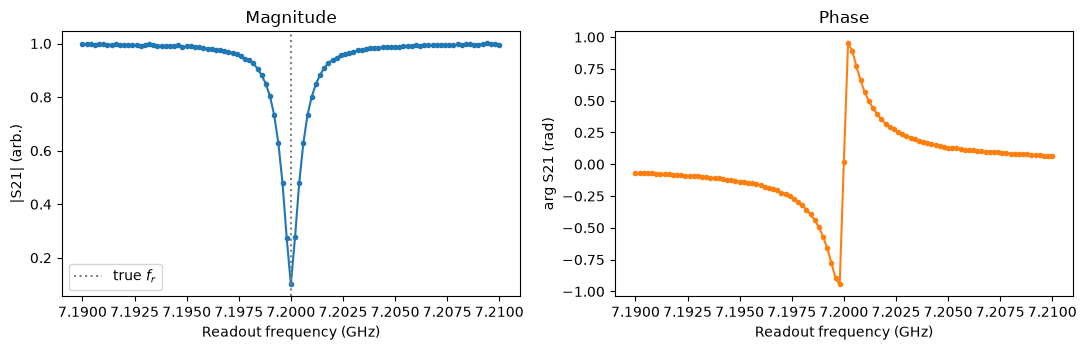

In [14]:
fig, (ax_mag, ax_phase) = plt.subplots(1, 2, figsize=(11, 3.6))

ax_mag.plot(freqs / 1e9, np.abs(s21_data), ".-")
ax_mag.axvline(DEVICE["q0_fr"] / 1e9, color="grey", ls=":", label="true $f_r$")
ax_mag.set(xlabel="Readout frequency (GHz)", ylabel="|S21| (arb.)", title="Magnitude")
ax_mag.legend()

ax_phase.plot(freqs / 1e9, np.unwrap(np.angle(s21_data)), ".-", color="tab:orange")
ax_phase.set(xlabel="Readout frequency (GHz)", ylabel="arg S21 (rad)", title="Phase")

fig.tight_layout()
plt.show()

### Reading the numbers off the curve

`argmin` is enough for the centre here, with one caveat worth saying out loud: it can never be
better than your step size. A 200 kHz grid gives you the resonator to 200 kHz, full stop. Part 3
fits a real curve and does better than the grid.

The width needs one step of care. The dip in $|S_{21}|$ is not a Lorentzian, so its half-depth
width is not $\kappa$. Subtract the off-resonance baseline and square what is left: $|S_{21} - 1|^2$
is a plain Lorentzian in power, and its full width at half maximum is $\kappa$ exactly. Reading the
half-maximum crossings with `np.interp` interpolates between grid points, which is how the number
below lands within 10 kHz on a 200 kHz grid.

In [15]:
f_dip = freqs[np.abs(s21_data).argmin()]

baseline = np.mean(np.concatenate([s21_data[:5], s21_data[-5:]]))   # flat away from resonance
lorentzian = np.abs(baseline - s21_data) ** 2
lorentzian = lorentzian / lorentzian.max()

peak = lorentzian.argmax()
left = np.interp(0.5, lorentzian[: peak + 1], freqs[: peak + 1])           # rising edge
right = np.interp(0.5, lorentzian[peak:][::-1], freqs[peak:][::-1])        # falling edge, reversed

print(f"f_r    measured {f_dip / 1e9:.6f} GHz    true {DEVICE['q0_fr'] / 1e9:.6f} GHz")
print(f"kappa  measured {(right - left) / 1e6:.3f} MHz     true {DEVICE['q0_kappa'] / 1e6:.3f} MHz")
print(f"sweep step {(freqs[1] - freqs[0]) / 1e3:.0f} kHz, so f_r is quantised to that")

f_r    measured 7.200000 GHz    true 7.200000 GHz
kappa  measured 1.509 MHz     true 1.500 MHz
sweep step 200 kHz, so f_r is quantised to that


## 2.6 Results are xarray, and the dimension names are yours

`qp.simulate` returns a `QProgramResult`: one record per `measure` call, keyed by the handle.
`result.get(handle)` hands you an `xarray.DataArray` whose dimensions are the enclosing sweeps,
outermost first, named after your **variable ids**, with the swept values as coordinates. Integrated
measurements carry one extra `IQ` axis of length two.

That is why the ids have to be identifiers: they are the dimension names you will type in `.sel()`
six months from now, and the identifiers in the `.qp` file. Pick them like you pick column names.

`label` and `units` do not travel into the coordinate attributes. Axis labels on your plots are
still your job.

`result.get(handle)` defaults to `field=MF.IQ`. Ask for a field the measurement never requested and
you get a `KeyError`, including the default, so a state-only measurement needs `field=MF.STATE`
spelled out.

<xarray.DataArray (ro_freq: 4, IQ: 2)> Size: 64B
array([[ 0.99538331, -0.06951379],
       [ 0.99463926, -0.06772279],
       [ 0.99424955, -0.0712499 ],
       [ 0.99247738, -0.07039821]])
Coordinates:
  * ro_freq  (ro_freq) float64 32B 7.19e+09 7.19e+09 7.19e+09 7.191e+09
  * IQ       (IQ) <U1 8B 'I' 'Q'

I at the resonator: 0.1005
asking for a field that was never requested: "Measurement 'q0/readout/m0' has no field 'state'; available: iq"


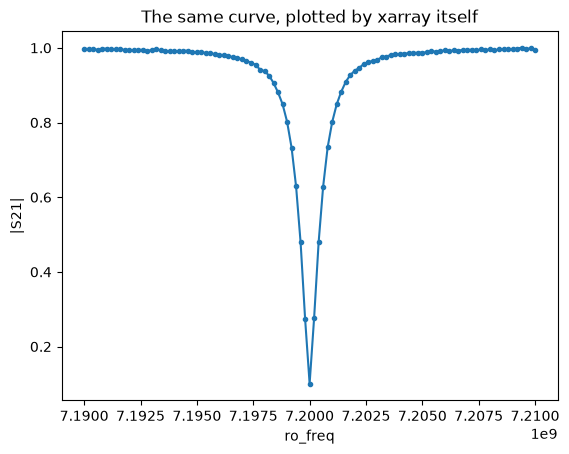

In [16]:
print(iq.isel(ro_freq=slice(0, 4)))   # the first four rows, so the repr fits on screen

# Label-based selection is the point of xarray: no index arithmetic, no guessing the axis order.
on_resonance = iq.sel(IQ="I").sel(ro_freq=DEVICE["q0_fr"], method="nearest")
print("\nI at the resonator:", round(float(on_resonance), 4))

try:
    result.get(m_spec, field=MF.STATE)   # this measurement asked for iq and nothing else
except KeyError as err:
    print("asking for a field that was never requested:", err)

magnitude = np.abs(iq.sel(IQ="I") + 1j * iq.sel(IQ="Q"))
magnitude.name = "|S21|"
magnitude.plot(marker=".")
plt.title("The same curve, plotted by xarray itself")
plt.show()

## 2.7 Punchout: nesting two sweeps

You have the resonator frequency at one particular readout power. That is not enough to set up
readout, because the resonator moves with power. At low power it sits at $f_r + \chi$, pulled by the
qubit it is coupled to. Drive it harder and the qubit saturates, the pull goes away, and the
resonator lands on its bare frequency $f_r$. The crossover is called punchout, and the map of it is
how you choose a readout power: low enough that the pull is still there, high enough to get signal.

Two nested `with` statements, two variables, and the outer one becomes the outer dimension. That is
the whole change to the program.

The cost model changes though. A 25 x 41 grid is 1025 points, so 200 shots each would be 205k
samples. Drop to 50 shots per point and the same scan is 51k samples, about a second. Shots x points
is the number to keep an eye on, in the simulator and on real hardware alike.

In [17]:
def s21_power(bus, env):
    """The resonator sits at f_r + chi at low power and slides to bare f_r as it saturates."""
    saturation = 1.0 / (1.0 + (env["ro_amp"] / 0.35) ** 2)
    f_eff = DEVICE["q0_fr"] + DEVICE["q0_chi"] * saturation
    detuning = (env["ro_freq"] - f_eff) / (DEVICE["q0_kappa"] / 2)
    return 1.0 - 0.9 / (1.0 + 1j * detuning)


punchout = qp.QProgram(label="punchout", schema=schema)
pun_amp = punchout.variable("ro_amp", label="Readout amplitude", units="V")
pun_freq = punchout.variable("ro_freq", label="Readout frequency", units="Hz")

with punchout.average(shots=50):
    with punchout.sweep(pun_amp, qp.Linspace(0.02, 1.0, 25)):
        with punchout.sweep(pun_freq, qp.Linspace(7.1955e9, 7.2025e9, 41)):
            punchout.set_gain(q[0].readout, pun_amp)
            punchout.set_frequency(q[0].readout, pun_freq)
            m_pun = punchout.measure(q[0].readout, "readout", "weights")

shot_loop = punchout.body.elements[0]          # Average
outer_sweep = shot_loop.elements[0]            # Sweep over ro_amp
inner_sweep = outer_sweep.elements[0]          # Sweep over ro_freq
print("points:", 25 * 41, "at 50 shots =", 25 * 41 * 50, "samples")
print(f"nesting: {type(shot_loop).__name__}({shot_loop.shots}) -> "
      f"{type(outer_sweep).__name__}({outer_sweep.variable.id}) -> "
      f"{type(inner_sweep).__name__}({inner_sweep.variable.id})")

points: 1025 at 50 shots = 51250 samples
nesting: Average(50) -> Sweep(ro_amp) -> Sweep(ro_freq)


dims: ('ro_amp', 'ro_freq', 'IQ') shape: (25, 41, 2) (outermost sweep first)


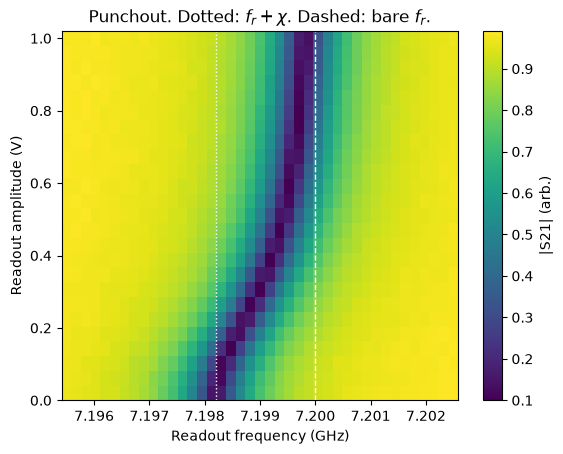

In [18]:
punch_model = qp.MockMeasurementModel(response=s21_power, noise=0.02, seed=11)
punch_iq = qp.simulate(punchout, model=punch_model).get(m_pun)
print("dims:", punch_iq.dims, "shape:", punch_iq.shape, "(outermost sweep first)")

punch_mag = np.abs(punch_iq.sel(IQ="I") + 1j * punch_iq.sel(IQ="Q")).values
amps = punch_iq.coords["ro_amp"].values
scan_freqs = punch_iq.coords["ro_freq"].values

plt.pcolormesh(scan_freqs / 1e9, amps, punch_mag, shading="nearest")
plt.colorbar(label="|S21| (arb.)")
plt.axvline((DEVICE["q0_fr"] + DEVICE["q0_chi"]) / 1e9, color="w", ls=":", lw=1)
plt.axvline(DEVICE["q0_fr"] / 1e9, color="w", ls="--", lw=1)
plt.xlabel("Readout frequency (GHz)")
plt.ylabel("Readout amplitude (V)")
plt.title(r"Punchout. Dotted: $f_r + \chi$. Dashed: bare $f_r$.")
plt.show()

In [19]:
dip_per_amp = scan_freqs[punch_mag.argmin(axis=1)]

for k in (0, 12, 24):
    print(f"amplitude {amps[k]:.2f} V  ->  dip at {dip_per_amp[k] / 1e9:.6f} GHz")
print(f"low-power target   f_r + chi = {(DEVICE['q0_fr'] + DEVICE['q0_chi']) / 1e9:.6f} GHz")
print(f"high-power target  bare f_r  = {DEVICE['q0_fr'] / 1e9:.6f} GHz")
print(f"frequency step {(scan_freqs[1] - scan_freqs[0]) / 1e3:.0f} kHz,"
      " which is all the accuracy an argmin can have")

amplitude 0.02 V  ->  dip at 7.198125 GHz
amplitude 0.51 V  ->  dip at 7.199350 GHz
amplitude 1.00 V  ->  dip at 7.199875 GHz
low-power target   f_r + chi = 7.198200 GHz
high-power target  bare f_r  = 7.200000 GHz
frequency step 175 kHz, which is all the accuracy an argmin can have


### The same scan as a diagonal: parallel loops

The map cost 1025 measurements and most of them were off resonance. Now that you know where the
ridge is, you can walk along it: step the amplitude and the frequency **together**, one point per
amplitude, 25 measurements instead of 1025.

`sweep(a, src) | sweep(b, src)` is that lockstep pair. Both loops advance on the same tick, so they
must have the same length. Every source can report its length without running, so the check happens
in `Parallel`'s constructor: mismatched lengths raise `ValidationError` on the `|` line itself, not
at run time. In the result the pair shares one dimension named `"ro_amp|ro_freq"`, carrying both
coordinate arrays.
Point $k$ of one is always paired with point $k$ of the other, and there is no grid.

The frequency list here comes from the map measured in the cell above, so it is a `Values`
source: arbitrary by construction, and honestly so. A diagonal is what you want whenever the
interesting region is a curve rather than a rectangle, which covers ridge tracking like this,
chevron cuts, and any scan where one parameter has to be compensated as another moves.

In [20]:
ridge = qp.QProgram(label="punchout_ridge", schema=schema)
d_amp = ridge.variable("ro_amp", label="Readout amplitude", units="V")
d_freq = ridge.variable("ro_freq", label="Readout frequency", units="Hz")

with ridge.average(shots=50):
    with ridge.sweep(d_amp, qp.Values(amps)) | ridge.sweep(d_freq, qp.Values(dip_per_amp)):
        ridge.set_gain(q[0].readout, d_amp)
        ridge.set_frequency(q[0].readout, d_freq)
        m_ridge = ridge.measure(q[0].readout, "readout", "weights")

ridge_iq = qp.simulate(
    ridge, model=qp.MockMeasurementModel(response=s21_power, noise=0.02, seed=11)
).get(m_ridge)
ridge_mag = np.abs(ridge_iq.sel(IQ="I") + 1j * ridge_iq.sel(IQ="Q")).values

print("dims:  ", ridge_iq.dims, ridge_iq.shape)
print("coords:", list(ridge_iq.coords))
print("measurements:", ridge_iq.sizes["ro_amp|ro_freq"], "against", 25 * 41, "for the full map")
print("|S21| along the ridge:", np.round(ridge_mag[:6], 3), "...")
print("still in the dip everywhere:", bool(ridge_mag.max() < 0.3))

dims:   ('ro_amp|ro_freq', 'IQ') (25, 2)
coords: ['ro_amp', 'ro_freq', 'IQ']
measurements: 25 against 1025 for the full map
|S21| along the ridge: [0.144 0.12  0.113 0.107 0.128 0.142] ...
still in the dip everywhere: True


### 🧩 Exercise 2.1: punchout on a log power axis

Readout power spans decades, and a linear amplitude axis wastes most of its points at the top end.
Redo the punchout with a log-spaced amplitude axis and pull out the punchout curve on its own.

1. Build the same program with `qp.Logspace(0.02, 1.0, 20)` for the amplitude and the same 41-point
   `Linspace` for the frequency. Keep `shots=50`.
2. Run it with `s21_power`.
3. Take the dip frequency per amplitude with `argmin(axis=1)` and plot it against amplitude on a
   `plt.semilogx` axis. Draw the two targets, $f_r + \chi$ and $f_r$, as horizontal lines.
4. Print `qp.Logspace(0.02, 1.0, 20).KIND` and write one comment line saying what that kind costs a
   platform.

The dip depth, by the way, does not move in this model: the response is always 90% deep, only the
centre slides. The position is what carries the information.

Logspace kind: arbitrary
0.020 V -> 7.198125 GHz, target f_r + chi = 7.198200
1.000 V -> 7.199875 GHz, target bare f_r = 7.200000


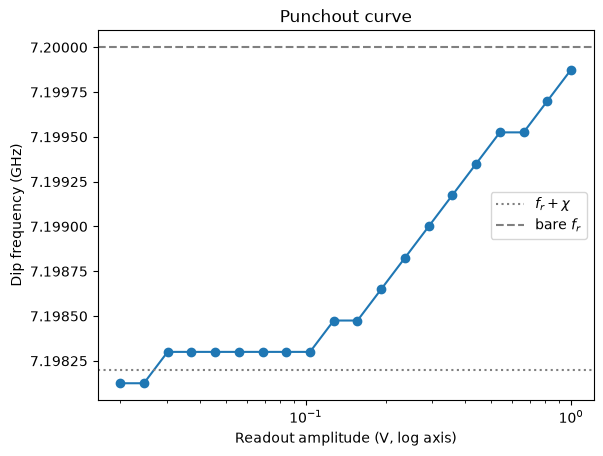

In [21]:
power_scan = qp.QProgram(label="punchout_log", schema=schema)
log_amp = power_scan.variable("ro_amp", label="Readout amplitude", units="V")
log_freq = power_scan.variable("ro_freq", label="Readout frequency", units="Hz")

with power_scan.average(shots=50):
    with power_scan.sweep(log_amp, qp.Logspace(0.02, 1.0, 20)):
        with power_scan.sweep(log_freq, qp.Linspace(7.1955e9, 7.2025e9, 41)):
            power_scan.set_gain(q[0].readout, log_amp)
            power_scan.set_frequency(q[0].readout, log_freq)
            m_log = power_scan.measure(q[0].readout, "readout", "weights")

log_iq = qp.simulate(
    power_scan, model=qp.MockMeasurementModel(response=s21_power, noise=0.02, seed=13)
).get(m_log)
log_amps = log_iq.coords["ro_amp"].values
log_freqs = log_iq.coords["ro_freq"].values
log_mag = np.abs(log_iq.sel(IQ="I") + 1j * log_iq.sel(IQ="Q")).values
log_dip = log_freqs[log_mag.argmin(axis=1)]

# Logspace is arbitrary: no sequencer register can produce it, so the platform either uploads
# the 20 values as a table or steps them one host round trip at a time.
print("Logspace kind:", qp.Logspace(0.02, 1.0, 20).KIND)
print(f"{log_amps[0]:.3f} V -> {log_dip[0] / 1e9:.6f} GHz, "
      f"target f_r + chi = {(DEVICE['q0_fr'] + DEVICE['q0_chi']) / 1e9:.6f}")
print(f"{log_amps[-1]:.3f} V -> {log_dip[-1] / 1e9:.6f} GHz, "
      f"target bare f_r = {DEVICE['q0_fr'] / 1e9:.6f}")

plt.semilogx(log_amps, log_dip / 1e9, "o-")
plt.axhline((DEVICE["q0_fr"] + DEVICE["q0_chi"]) / 1e9, color="grey", ls=":", label=r"$f_r + \chi$")
plt.axhline(DEVICE["q0_fr"] / 1e9, color="grey", ls="--", label=r"bare $f_r$")
plt.xlabel("Readout amplitude (V, log axis)")
plt.ylabel("Dip frequency (GHz)")
plt.title("Punchout curve")
plt.legend()
plt.show()

### 🧩 Exercise 2.2: two resonators in one pass

Qubit 1 has its own readout resonator at 7.35 GHz. Its band does not overlap qubit 0's, so scanning
them one after the other doubles your measurement time for no reason. Sweep both frequencies in
lockstep instead and measure both buses at every point.

1. Declare two variables, `f0` and `f1`, and sweep them in parallel with
   `sweep(f0, ...) | sweep(f1, ...)`. Give each a 41-point `Linspace` over its own 10 MHz band
   (`7.195` to `7.205` GHz, and `7.345` to `7.355` GHz). Use `shots=100`.
2. Inside the loop, `set_frequency` on each readout bus and `measure` both. You get two handles.
3. Write one response function for both resonators. It receives `bus`, so it can pick which
   frequency and which centre to use. `q1_fr` is in `DEVICE`.
4. Print the dims of each record and the dip frequency each one found. Then write a comment
   explaining why there is one dimension of length 41 here and not a 41 x 41 grid.

q0/readout/m0: dims=('f0|f1', 'IQ'), dip 7.2000 GHz, true 7.2000 GHz
q1/readout/m0: dims=('f0|f1', 'IQ'), dip 7.3500 GHz, true 7.3500 GHz


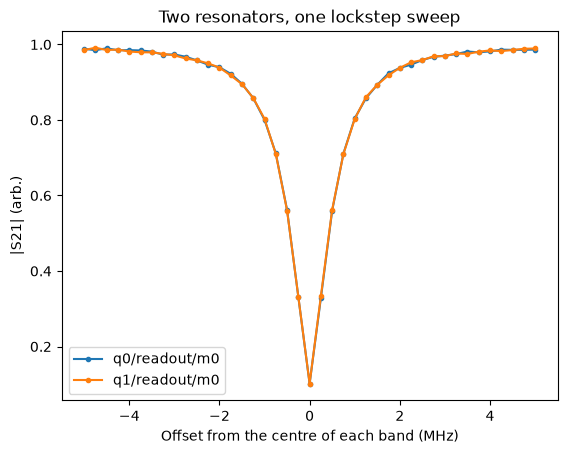

In [22]:
def s21_pair(bus, env):
    """One model, two resonators. The bus argument says which one is being measured."""
    if bus == q[0].readout:
        detuning = (env["f0"] - DEVICE["q0_fr"]) / (DEVICE["q0_kappa"] / 2)
    else:
        # DEVICE carries no q1 linewidth, so q0's stands in. Nothing here measures it.
        detuning = (env["f1"] - DEVICE["q1_fr"]) / (DEVICE["q0_kappa"] / 2)
    return 1.0 - 0.9 / (1.0 + 1j * detuning)


pair = qp.QProgram(label="two_resonators", schema=schema)
f0 = pair.variable("f0", label="q0 readout frequency", units="Hz")
f1 = pair.variable("f1", label="q1 readout frequency", units="Hz")

with pair.average(shots=100):
    band_0 = pair.sweep(f0, qp.Linspace(7.195e9, 7.205e9, 41))
    band_1 = pair.sweep(f1, qp.Linspace(7.345e9, 7.355e9, 41))
    with band_0 | band_1:
        pair.set_frequency(q[0].readout, f0)
        pair.set_frequency(q[1].readout, f1)
        m_q0 = pair.measure(q[0].readout, "readout", "weights")
        m_q1 = pair.measure(q[1].readout, "readout", "weights")

pair_model = qp.MockMeasurementModel(response=s21_pair, noise=0.02, seed=5)
pair_result = qp.simulate(pair, model=pair_model)

# The two loops advance on the same tick, so they share one dimension, "f0|f1", of length 41,
# carrying two coordinate arrays. Point k of f0 is always measured with point k of f1. A 41 x 41
# grid would need the loops nested, and 1681 points instead of 41.
for handle, coord, truth in ((m_q0, "f0", DEVICE["q0_fr"]), (m_q1, "f1", DEVICE["q1_fr"])):
    da = pair_result.get(handle)
    mag = np.abs(da.sel(IQ="I") + 1j * da.sel(IQ="Q")).values
    axis = da.coords[coord].values
    found = axis[mag.argmin()] / 1e9
    print(f"{handle.name}: dims={da.dims}, dip {found:.4f} GHz, true {truth / 1e9:.4f} GHz")
    plt.plot((axis - axis.mean()) / 1e6, mag, ".-", label=handle.name)

plt.xlabel("Offset from the centre of each band (MHz)")
plt.ylabel("|S21| (arb.)")
plt.title("Two resonators, one lockstep sweep")
plt.legend()
plt.show()

## Recap and what is next

- A **variable** is a hole in the program, and the loop that binds it decides what goes in.
  Expressions built on top of it re-evaluate every iteration, waveform parameters included.
- A **sweep source** says how the variable moves. `Range` and `Linspace` are `linear`, so a
  sequencer can run them from a register. `Values`, `Logspace`, `File` and the combinators are
  `arbitrary`, and a platform pays for that in table space or host round trips. `Range` includes its
  stop value. `Values` stays arbitrary even when its numbers are evenly spaced.
- **`average(shots)` adds no dimension.** It shrinks the noise on `iq` as $1/\sqrt{N}$ and turns
  `state` from a 0/1 outcome into a population.
- The **measurement model** is the fake fridge, and it is the only thing in the loop that produces a
  number. No timing, no pulse physics. The program and the analysis are the real parts.
- Results are **xarray**, one dimension per enclosing sweep, outermost first, named after your
  variable ids, with one shared `"a|b"` dimension for a parallel pair.
- You now have the resonator: 7.200 GHz, 1.5 MHz wide, and a punchout map that says what power to
  read out at. Part 3 puts a second tone on the drive line and goes looking for the qubit itself.